# SALT3 - Run-Scoped CPT Training

This notebook trains, resumes, or continues one CPT run. All mutable state is isolated under `/content/drive/MyDrive/SALT3/runs/<RUN_NAME>/`.

In [1]:
from huggingface_hub import login
try:
    from google.colab import userdata
    login(token=userdata.get('HF_TOKEN'))
except Exception:
    import os
    if os.environ.get('HF_TOKEN'):
        login(token=os.environ['HF_TOKEN'])

In [2]:
%%capture
!pip install -U "huggingface_hub>=1.13.0" transformers accelerate datasets safetensors sentencepiece tokenizers pandas scikit-learn matplotlib tqdm
# NO xformers on purpose: NeoBERT's fused xformers SwiGLU returns NaN on some torch/CUDA
# builds (torch 2.11/cu128), and a present-but-broken wheel is picked up silently. The init
# artifacts are patched (salt3_common) to use a pure-torch SwiGLU unconditionally, so the
# forward is finite and version-robust without xformers. Removing a stale wheel guarantees it:
!pip uninstall -y xformers

In [3]:
from pathlib import Path
import gc
import shutil
import sys

import torch
import transformers
from transformers import AutoModelForMaskedLM, AutoTokenizer, EarlyStoppingCallback

try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as exc:
    print('Drive mount skipped:', exc)

PROJECT_ROOT = Path('/content/drive/MyDrive/SALT3') if Path('/content/drive/MyDrive').exists() else Path.cwd() / 'SALT3'
CODE_DIR = PROJECT_ROOT / 'code'
CODE_DIR.mkdir(parents=True, exist_ok=True)
for import_path in ('/content', str(CODE_DIR), str(PROJECT_ROOT)):
    if import_path not in sys.path:
        sys.path.insert(0, import_path)

import salt3_common as _salt3_common
print('salt3_common:', _salt3_common.__file__)

from salt3_common import (
    JsonlMetricsCallback, configure_environment, copy_neobert_remote_files,
    create_or_load_run, diagnose_model_health, embedding_fingerprint, ensure_dir,
    eval_with_perplexity, get_last_checkpoint, inspect_tokenized_dataset,
    load_model_safe, make_mlm_collator, make_mlm_datasets, make_neo_mlm_trainer_class,
    plot_training_curves, resolve_ref, set_seed, tokenizer_fingerprint,
    train_with_run_resume, training_args, validate_model_artifact, write_json,
)

configure_environment()
set_seed(42)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
NeoMLMTrainer = make_neo_mlm_trainer_class()
print('Device:', DEVICE)
print('Project root:', PROJECT_ROOT)
# The install cell is %%capture'd, so report what actually got installed —
# a silently swapped torch/transformers is otherwise invisible until mid-run.
print('Versions: torch', torch.__version__, '| transformers', transformers.__version__)
try:
    import xformers
    print('xformers:', xformers.__version__)
except Exception as exc:
    print('xformers unavailable — pure-PyTorch SwiGLU fallback will be used:', exc)

Mounted at /content/drive
salt3_common: /content/drive/MyDrive/SALT3/code/salt3_common.py
Device: cuda
Project root: /content/drive/MyDrive/SALT3
Versions: torch 2.11.0+cu128 | transformers 5.11.0
xformers unavailable — pure-PyTorch SwiGLU fallback will be used: No module named 'xformers'


## Configure this run

Set `MODE`, `RUN_NAME`, and `BASE_MODEL_REF`. For `resume`, `BASE_MODEL_REF` is loaded from the existing run config.

In [8]:
MODE = 'new'  # 'new', 'resume', or 'continue'
RUN_NAME = 'fix-swiglu'
# Point at the init that wins the bake-off (notebook 04, section I). Candidates:
#   init/videberta_salt_init_v5_globalmap_freqbias/model   (v5 LLE)
#   init/videberta_procrustes_init_v6/model                (Procrustes, ViDeBERTa donor)
#   init/phobert_procrustes_init_v6/model                  (Procrustes, PhoBERT donor)
BASE_MODEL_REF = 'init/videberta_salt_init_v5_globalmap_freqbias/model'  # certified finite by nb10; swap after donor study concludes
ALLOW_OVERWRITE = False
# NOTE: with MODE='resume', the values below are read from the run's saved
# run_config.json — any edits here are reported as ignored, not applied.

DATA_CONFIG = {
    # num_examples: how many CulturaX docs to stream & tokenize (cached to Drive).
    # Cache is keyed by (num_examples, max_seq_len, eval_ratio, seed, tokenizer
    # fingerprint); documents are routed to train/eval BEFORE chunk packing so no
    # document leaks across the split. If the pruned tokenizer changes, SALT3
    # rebuilds the cache instead of silently reusing stale token IDs.
    # Tip: set this to your LARGEST planned experiment (e.g. 3_000_000),
    # then use num_chunks to take a smaller slice for quick experiments.
    'num_examples': 40_000,
    'max_seq_len': 1024,
    # num_chunks: how many chunks to actually USE from the tokenizer-specific cache.
    # None = use all chunks from the 3M-doc cache for the full run.
    # Set to e.g. 40_000 or 400_000 for smaller experiments without re-tokenizing.
    'num_chunks': None,
    'eval_ratio': 0.02,
    'mlm_probability': 0.20,
    'seed': 42,
}

TRAIN_CONFIG = {
    'run_name': RUN_NAME,
    'num_train_epochs': 1,
    'max_steps': -1,
    'per_device_train_batch_size': 32,
    'per_device_eval_batch_size': 32,
    'gradient_accumulation_steps': 16,
    'learning_rate': 1e-4,
    'adam_beta2': 0.95,
    'weight_decay': 0.01,
    'warmup_ratio': 0.05,
    'logging_steps': 25,
    'eval_steps': 200,
    'save_steps': 200,
    'save_total_limit': 5,
    'early_stopping_patience': 5,
}

RUN_CONFIG = {
    'strategy': 'simple_cpt',
    'seed': 42,
    'data': DATA_CONFIG,
    'training': TRAIN_CONFIG,
}

run = create_or_load_run(
    PROJECT_ROOT,
    mode=MODE,
    run_name=RUN_NAME,
    base_model_ref=BASE_MODEL_REF,
    config=RUN_CONFIG,
    allow_overwrite=ALLOW_OVERWRITE,
)
BASE_MODEL_PATH = resolve_ref(PROJECT_ROOT, run['base_model_ref'])
CHECKPOINT_DIR = Path(run['checkpoint_dir'])
FINAL_MODEL_DIR = Path(run['final_model_dir'])
METRICS_PATH = Path(run['metrics_path'])
PLOTS_DIR = Path(run['plots_dir'])
DATASET_CACHE = ensure_dir(PROJECT_ROOT / 'datasets')

print('Mode           :', MODE)
print('Run name       :', run['run_name'])
print('Run dir        :', run['run_dir'])
print('Base model ref :', run['base_model_ref'])
print('Base model path:', BASE_MODEL_PATH)
print('Checkpoint dir :', CHECKPOINT_DIR)
print('Final model dir:', FINAL_MODEL_DIR)

Mode           : new
Run name       : fix-swiglu
Run dir        : /content/drive/MyDrive/SALT3/runs/fix-swiglu
Base model ref : init/videberta_salt_init_v5_globalmap_freqbias/model
Base model path: /content/drive/MyDrive/SALT3/init/videberta_salt_init_v5_globalmap_freqbias/model
Checkpoint dir : /content/drive/MyDrive/SALT3/runs/fix-swiglu/checkpoints
Final model dir: /content/drive/MyDrive/SALT3/runs/fix-swiglu/final_model


In [9]:
import json

validate_model_artifact(BASE_MODEL_PATH)
salt_cfg_path = BASE_MODEL_PATH.parent / 'salt_config.json'
if salt_cfg_path.exists():
    salt_cfg = json.loads(salt_cfg_path.read_text(encoding='utf-8'))
    print('Decoder init  :', salt_cfg.get('decoder_init', 'unknown'))
    print('Special rows  :', salt_cfg.get('special_token_init', 'unknown'))
    decoder_init = salt_cfg.get('decoder_init', '')
    if decoder_init not in ('projected_from_neobert_decoder', 'tied_to_embeddings', 'global_emb_to_decoder_map'):
        print('WARNING: init artifact has unrecognized decoder_init; pre-train MLM loss may be dominated by a random LM head.')
    if salt_cfg.get('special_token_init') != 'copied_from_neobert_specials':
        print('WARNING: init artifact does not record copied NeoBERT special-token rows; MLM eval can fail even when normal token embeddings look healthy.')
else:
    print('WARNING: salt_config.json not found next to base model; cannot verify decoder init.')

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_PATH, trust_remote_code=True)
model = load_model_safe(BASE_MODEL_PATH, model_cls=AutoModelForMaskedLM, device=DEVICE)
fingerprint = embedding_fingerprint(model)
tok_fp = tokenizer_fingerprint(tokenizer)
write_json(Path(run['run_dir']) / 'base_embedding_fingerprint.json', fingerprint)
write_json(Path(run['run_dir']) / 'tokenizer_fingerprint.json', tok_fp)
print('Tokenizer vocab:', len(tokenizer))
print('Model vocab    :', model.config.vocab_size)
print('Tokenizer fp   :', tok_fp)
print('Embedding fp   :', fingerprint)

# Diagnose whether model weights loaded correctly — and HALT on failure: a printed
# warning scrolls past under 'Run all' and a broken load wastes the whole session.
health = diagnose_model_health(model, tokenizer, device=DEVICE)
if not str(health.get('diagnosis', '')).startswith('OK'):
    raise RuntimeError(
        f"Model health check failed: {health.get('diagnosis')!r}. "
        'Fix the init artifact / weight loading before training.'
    )

Decoder init  : global_emb_to_decoder_map
Special rows  : copied_from_neobert_specials
  ✓ load_model_safe: all 172 keys loaded successfully
Tokenizer vocab: 30522
Model vocab    : 30522
Tokenizer fp   : {'sha256': '3487ef147c62b5d643c49864a9774f364099446872110282fb37e2bad6b3c552', 'short': '3487ef147c62', 'tokenizer_class': 'DebertaV2Tokenizer', 'vocab_size': 30522, 'special_ids': {'pad': 0, 'unk': 3, 'mask': 4, 'bos': 1, 'eos': 2, 'cls': 1, 'sep': 2}, 'sample_ids': [[1049, 1648, 358, 627], [1603, 345, 971, 1960, 71, 188, 7], [11631, 716, 4202, 5239, 177, 214, 358, 7]]}
Embedding fp   : {'shape': [30522, 768], 'mean_norm': 1.218300223350525, 'std_norm': 0.038181208074092865, 'sha256_first_rows': 'c8602bf4b19c04630c743797fdaf941a19a10d6c01e07220941e9a378e9978f2'}
── Model health diagnostic ──
  Vocab size              : 30522
  Expected random loss    : 10.33  (= log(30522))
  Embedding mean norm     : 1.2183
  Embedding std norm      : 0.0382
  Encoder mean weight std : 0.041642
  Enc

In [10]:
data_cfg = run['data']
train_dataset, eval_dataset = make_mlm_datasets(
    tokenizer=tokenizer,
    cache_dir=DATASET_CACHE,
    num_examples=data_cfg['num_examples'],
    max_seq_len=data_cfg['max_seq_len'],
    num_chunks=data_cfg.get('num_chunks'),  # None = use all cached chunks
    eval_ratio=data_cfg['eval_ratio'],
    seed=data_cfg['seed'],
)
inspect_tokenized_dataset(train_dataset, tokenizer, name='train')
inspect_tokenized_dataset(eval_dataset, tokenizer, name='eval')
data_collator = make_mlm_collator(tokenizer, mlm_probability=data_cfg['mlm_probability'])
pre_rows = [train_dataset[i] for i in range(min(4, len(train_dataset)))]
original_ids = torch.tensor([row['input_ids'] for row in pre_rows], dtype=torch.long)
sample = data_collator(pre_rows)
masked_positions = sample['labels'] != -100
mask_token_id = tokenizer.mask_token_id
masked_total = int(masked_positions.sum())
mask_replaced = int((sample['input_ids'][masked_positions] == mask_token_id).sum())
kept_same = int((sample['input_ids'][masked_positions] == original_ids[masked_positions]).sum())
random_replaced = masked_total - mask_replaced - kept_same
print('Train chunks:', len(train_dataset), 'Eval chunks:', len(eval_dataset))
print('Sample batch:', tuple(sample['input_ids'].shape), 'masked:', masked_total)
print(
    'Mask replacement:',
    f'[MASK]={mask_replaced}/{masked_total} ({mask_replaced/max(masked_total, 1):.1%}) |',
    f'same={kept_same}/{masked_total} ({kept_same/max(masked_total, 1):.1%}) |',
    f'random={random_replaced}/{masked_total} ({random_replaced/max(masked_total, 1):.1%})',
)

Tokenizer fingerprint: 3487ef147c62 (DebertaV2Tokenizer, vocab=30522)
Dataset cache key    : culturax_vi_40000_seq1024_tok3487ef147c62_ev0.02_s42_docsplit
Streaming 40,000 CulturaX-vi docs (this is the slow part, ~1 hr for 3M)...
  Result will be cached to /content/drive/MyDrive/SALT3/datasets/culturax_vi_40000_seq1024_tok3487ef147c62_ev0.02_s42_docsplit for instant reload next time.


Resolving data files:   0%|          | 0/90 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

  Total: 40,000 docs -> 37,972 chunks of 1024 tokens


Filter:   0%|          | 0/37972 [00:00<?, ? examples/s]

Filter:   0%|          | 0/37972 [00:00<?, ? examples/s]

  Saving cache to /content/drive/MyDrive/SALT3/datasets/culturax_vi_40000_seq1024_tok3487ef147c62_ev0.02_s42_docsplit ...


Saving the dataset (0/1 shards):   0%|          | 0/37218 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/754 [00:00<?, ? examples/s]

  Cache saved (37,218 train + 754 eval)
  Using 37,218 train + 754 eval chunks
── Tokenized train sanity ──
  Rows: 37,218
  Example 0: len=1024 min_id=3 max_id=28179 oob=0 unk=8
    decode: Cargill khai trương nhà máy thức ăn chăn nuôi trị giá 8,5 triệu USD TRANG VÀNG NÔNG NGHIỆP VIỆT NAM Đây là nhà máy thức ăn chăn nuôi thứ 11 của Cargill tại Việt Nam với công suất 66.000 tấn thức ăn gia súc/năm. Cũng trong năm 2016, Cargill sẽ đầu tư thêm một dây chuyền sản xuất T[UNK]CN trị giá 8 triệu USD cho nhà máy tại Đồng Tháp. Được biết kế hoạch phát triển năm 2017 của Cargill tại Việt Nam là tiếp tục đầu tư xây dựng một nhà máy T[UNK]CN mới tại Bình Dương có số vốn đầu tư 30 triệu USD với
  Example 1: len=1024 min_id=5 max_id=30201 oob=0 unk=0
    decode: thực lực rất cường đại. Người thân bí Lôi vẫn còn cam đảm khiêu chiến. Đây là ngu xuẩn hay là can đảm? Cam Mặc Lôi cẩn thận nhìn Lâm Lôi một lần nữa. "Đương nhiên, ta cũng có thể không khiên chiến." Lâm Lôi đột nhiên nói. "Sao?" Xích Nham l

In [11]:
train_cfg = dict(run['training'])
early_stopping_patience = train_cfg.pop('early_stopping_patience', 5)
args = training_args(CHECKPOINT_DIR, **train_cfg)
metrics = JsonlMetricsCallback(METRICS_PATH)
effective_batch_size = args.per_device_train_batch_size * args.gradient_accumulation_steps
estimated_optimizer_steps = max(1, (len(train_dataset) + effective_batch_size - 1) // effective_batch_size)
estimated_training_evals = estimated_optimizer_steps // args.eval_steps
trainer = NeoMLMTrainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=data_collator,
    processing_class=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=early_stopping_patience), metrics.callback],
)
print('Trainer GA normalization on (model_accepts_loss_kwargs=False):', not trainer.model_accepts_loss_kwargs)
checkpoint = get_last_checkpoint(CHECKPOINT_DIR)
print('Early stopping patience:', early_stopping_patience)
print('Estimated optimizer steps:', estimated_optimizer_steps)
print('Estimated training evals :', estimated_training_evals)
if estimated_training_evals <= early_stopping_patience:
    print('Warning: early stopping is unlikely to trigger with the current eval cadence.')
print('Existing checkpoint:', checkpoint)

import math
if masked_total == 0:
    # zero masked tokens is the most broken collator state, not a pass
    raise RuntimeError(
        'MLM collator masked 0 tokens in the probe batch — the objective is broken '
        '(check mlm_probability and the special-token mask).'
    )
if mask_replaced != masked_total:
    print(
        'WARNING: MLM collator is not doing full [MASK] replacement.',
        'This makes the pre-train eval non-comparable to NeoBERT pretraining and can inflate loss dramatically.',
    )
pre = eval_with_perplexity(trainer)
expected_random = math.log(model.config.vocab_size)
print(f'Pre-train eval      : {pre}')
print(f'Expected random loss: {expected_random:.2f} (= log({model.config.vocab_size}))')
if math.isnan(pre['eval_loss']):
    raise RuntimeError(
        'Pre-train eval_loss is NaN — eval batches likely contain no masked labels, '
        'or the forward pass produced NaNs.'
    )
if pre['eval_loss'] > expected_random * 1.2:
    print(f'⚠ eval_loss ({pre["eval_loss"]:.2f}) >> random ({expected_random:.2f}) — model is confidently wrong on this eval set.')
    print('  First suspect: MLM objective mismatch. Confirm the batch above shows 100% [MASK], 0% same, 0% random.')
    print('  Second suspect: stale tokenized dataset cache or tokenizer/id mismatch. Check the dataset cache key and decoded samples above.')
    print('  If both look correct, the remaining issue is init quality itself (projection/anchor coverage), not checkpoint loading.')
    if checkpoint is None:
        # only halt FRESH runs: a resumed run continues from trained checkpoint
        # weights, so the base model scoring badly here does not affect it
        raise RuntimeError(
            'Refusing to start a fresh CPT run from an init that scores worse than random — '
            'training would burn the session on a broken model.'
        )
    print('  Continuing: an existing checkpoint will be resumed, so the base-model score above is not what trains.')
elif pre['eval_loss'] < expected_random * 0.8:
    print(f'✓ eval_loss ({pre["eval_loss"]:.2f}) < random ({expected_random:.2f}) — init/tokenizer/dataset are aligned.')
else:
    print('Eval is near random. That can happen for a fresh init, but it should improve quickly during CPT if the objective and dataset are aligned.')

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Trainer GA normalization on (model_accepts_loss_kwargs=False): True
Early stopping patience: 5
Estimated optimizer steps: 73
Estimated training evals : 0
Existing checkpoint: None


Training Loss,Validation Loss,Step
No log,7.246743,0


Pre-train eval      : {'eval_loss': 7.2467427253723145, 'eval_perplexity': 1403.5257257877952}
Expected random loss: 10.33 (= log(30522))
✓ eval_loss (7.25) < random (10.33) — init/tokenizer/dataset are aligned.


In [12]:
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    free, total = torch.cuda.mem_get_info()
    print(f'VRAM after cleanup: {free / 1e9:.1f}GB free / {total / 1e9:.1f}GB total')

VRAM after cleanup: 83.5GB free / 85.1GB total


In [13]:
result = train_with_run_resume(trainer, MODE)
post = eval_with_perplexity(trainer)
print('Global steps:', result.global_step)
print('Post-train eval:', post)
if 'eval_loss' in pre and 'eval_loss' in post:
    improved = post['eval_loss'] < pre['eval_loss']
    print(f'Loss improved: {"✓ YES" if improved else "✗ NO"} '
          f'({pre["eval_loss"]:.4f} → {post["eval_loss"]:.4f})')

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Step,Training Loss,Validation Loss
73,6.483406,5.839234


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Step
6.483406,5.840449,73


Global steps: 73
Post-train eval: {'eval_loss': 5.840449333190918, 'eval_perplexity': 343.9338468428566}
Loss improved: ✓ YES (7.2467 → 5.8404)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

model.py:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

rotary.py:   0%|          | 0.00/2.58k [00:00<?, ?B/s]

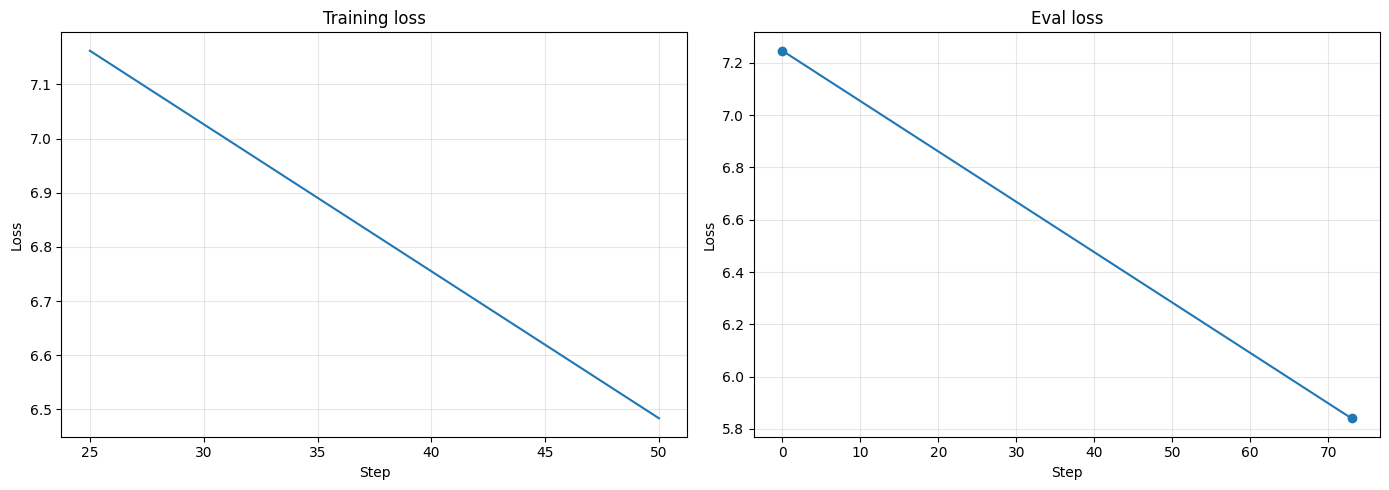

Saved final model: /content/drive/MyDrive/SALT3/runs/fix-swiglu/final_model
Final embedding fp: {'shape': [30522, 768], 'mean_norm': 1.2185763120651245, 'std_norm': 0.03813399001955986, 'sha256_first_rows': '6c69198f3b651626fe3945193de04c45150d138d5a3cb490df1d7ef78163fa53'}


In [14]:
FINAL_MODEL_DIR.mkdir(parents=True, exist_ok=True)
trainer.save_model(FINAL_MODEL_DIR)
tokenizer.save_pretrained(FINAL_MODEL_DIR)
copy_neobert_remote_files(FINAL_MODEL_DIR)
final_fp = embedding_fingerprint(trainer.model)
write_json(Path(run['run_dir']) / 'final_embedding_fingerprint.json', final_fp)
plot_training_curves(METRICS_PATH, save_path=PLOTS_DIR / 'loss_curves.png')
print('Saved final model:', FINAL_MODEL_DIR)
print('Final embedding fp:', final_fp)
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()